# Wikipedia Vote Network Exploration

This notebook explores the cleaned Wikipedia Vote Network and prepares report-ready observations for the GraphRAG assignment.

Main goals:
- load the processed edge list
- build the directed graph
- inspect graph statistics and degree distributions
- check the train/test split files
- save a few figures for the final report

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display

plt.style.use("ggplot")
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root from the current notebook location.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
RAW_PATH = DATA_DIR / "raw" / "wiki-Vote.txt"
PROCESSED_PATH = DATA_DIR / "processed" / "graph_edges.csv"
TRAIN_PATH = DATA_DIR / "splits" / "train_edges.csv"
TEST_PATH = DATA_DIR / "splits" / "test_edges.csv"
NEGATIVE_PATH = DATA_DIR / "splits" / "negative_samples.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root: {PROJECT_ROOT}")


Project root: c:\Users\User\OneDrive\UTS\4th semester\4 - 42913 Social and Information Network Analysis\Social_and_Internet_Network_GraphRAG


In [2]:
path_status = pd.DataFrame(
    [
        {"file": "raw dataset", "path": RAW_PATH, "exists": RAW_PATH.exists()},
        {"file": "processed edges", "path": PROCESSED_PATH, "exists": PROCESSED_PATH.exists()},
        {"file": "train split", "path": TRAIN_PATH, "exists": TRAIN_PATH.exists()},
        {"file": "test split", "path": TEST_PATH, "exists": TEST_PATH.exists()},
        {"file": "negative samples", "path": NEGATIVE_PATH, "exists": NEGATIVE_PATH.exists()},
    ]
)
path_status["path"] = path_status["path"].astype(str)
display(path_status)


,file,path,exists
0,raw dataset,c:\Users\User\OneDrive\UTS\4th semester\4 - 42...,True
1,processed edges,c:\Users\User\OneDrive\UTS\4th semester\4 - 42...,True
2,train split,c:\Users\User\OneDrive\UTS\4th semester\4 - 42...,True
3,test split,c:\Users\User\OneDrive\UTS\4th semester\4 - 42...,True
4,negative samples,c:\Users\User\OneDrive\UTS\4th semester\4 - 42...,True


## Load The Processed Edge List

This notebook expects the cleaned CSV created by `scripts/preprocess_data.py`. If the file is still empty, run the preprocessing script first.

In [3]:
edges = pd.read_csv(PROCESSED_PATH)
if edges.empty:
    raise ValueError(
        f"{PROCESSED_PATH} is empty. Run scripts/preprocess_data.py after downloading the SNAP dataset."
    )

edges = edges[["source", "target"]].astype(int)
G = nx.from_pandas_edgelist(edges, source="source", target="target", create_using=nx.DiGraph())

print(f"Loaded {len(edges):,} directed edges")
print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")
display(edges.head(10))


Loaded 103,689 directed edges
Graph nodes: 7,115
Graph edges: 103,689


,source,target
0,30,1412
1,30,3352
2,30,5254
3,30,5543
4,30,7478
5,3,28
6,3,30
7,3,39
8,3,54
9,3,108


In [4]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_in_degree = sum(dict(G.in_degree()).values()) / num_nodes
avg_out_degree = sum(dict(G.out_degree()).values()) / num_nodes
reciprocity = nx.reciprocity(G)
weak_components = nx.number_weakly_connected_components(G)
strong_components = nx.number_strongly_connected_components(G)
largest_wcc = max((len(component) for component in nx.weakly_connected_components(G)), default=0)
largest_scc = max((len(component) for component in nx.strongly_connected_components(G)), default=0)

summary_df = pd.DataFrame(
    {
        "metric": [
            "number_of_nodes",
            "number_of_edges",
            "density",
            "average_in_degree",
            "average_out_degree",
            "reciprocity",
            "weakly_connected_components",
            "strongly_connected_components",
            "largest_weak_component_size",
            "largest_strong_component_size",
        ],
        "value": [
            num_nodes,
            num_edges,
            density,
            avg_in_degree,
            avg_out_degree,
            reciprocity,
            weak_components,
            strong_components,
            largest_wcc,
            largest_scc,
        ],
    }
)
display(summary_df)


,metric,value
0,number_of_nodes,"7,115.0000"
1,number_of_edges,"103,689.0000"
2,density,0.0020
3,average_in_degree,14.5733
4,average_out_degree,14.5733
5,reciprocity,0.0565
6,weakly_connected_components,24.0000
7,strongly_connected_components,"5,816.0000"
8,largest_weak_component_size,"7,066.0000"
9,largest_strong_component_size,"1,300.0000"


## Degree Distributions

The in-degree captures how many votes a user receives, while the out-degree captures how many votes a user gives.

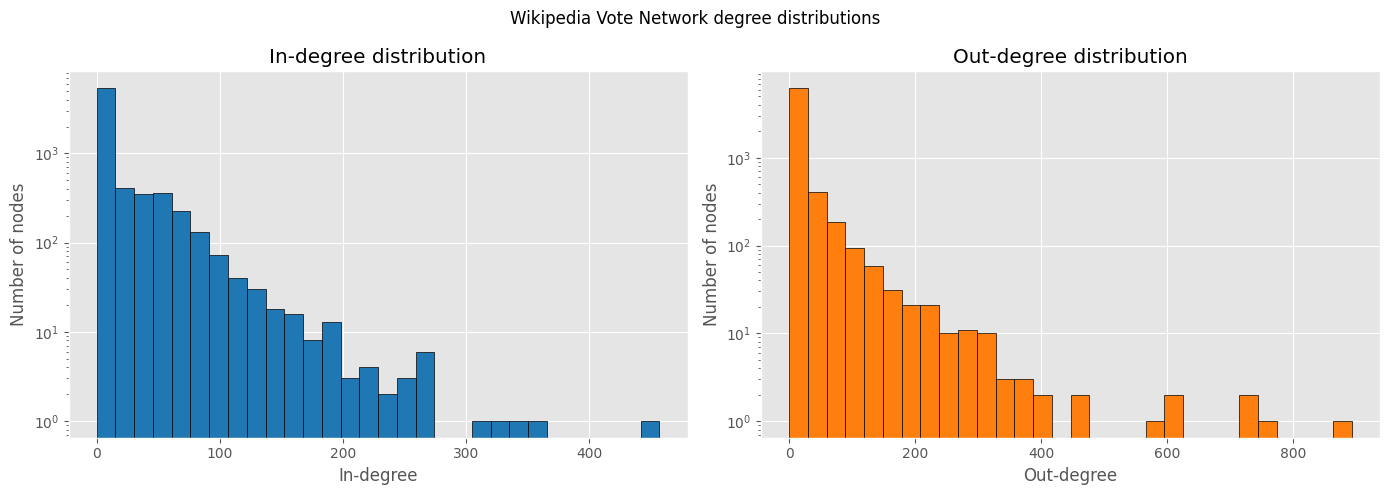

Saved figure to: c:\Users\User\OneDrive\UTS\4th semester\4 - 42913 Social and Information Network Analysis\Social_and_Internet_Network_GraphRAG\reports\figures\degree_distributions.png


In [5]:
in_degree = pd.Series(dict(G.in_degree()), name="in_degree")
out_degree = pd.Series(dict(G.out_degree()), name="out_degree")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(in_degree, bins=30, color="#1f77b4", edgecolor="black")
axes[0].set_title("In-degree distribution")
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Number of nodes")
axes[0].set_yscale("log")

axes[1].hist(out_degree, bins=30, color="#ff7f0e", edgecolor="black")
axes[1].set_title("Out-degree distribution")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Number of nodes")
axes[1].set_yscale("log")

fig.suptitle("Wikipedia Vote Network degree distributions")
fig.tight_layout()

degree_figure_path = FIGURES_DIR / "degree_distributions.png"
fig.savefig(degree_figure_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {degree_figure_path}")


In [6]:
top_in_degree = (
    in_degree.sort_values(ascending=False)
    .head(10)
    .rename_axis("node")
    .reset_index(name="in_degree")
)
top_out_degree = (
    out_degree.sort_values(ascending=False)
    .head(10)
    .rename_axis("node")
    .reset_index(name="out_degree")
)

print("Top 10 users by received votes")
display(top_in_degree)
print("Top 10 users by cast votes")
display(top_out_degree)


Top 10 users by received votes


,node,in_degree
0,4037,457
1,15,361
2,2398,340
3,2625,331
4,1297,309
5,2565,274
6,762,272
7,2328,266
8,5254,265
9,3352,264


Top 10 users by cast votes


,node,out_degree
0,2565,893
1,766,773
2,11,743
3,457,732
4,2688,618
5,1166,599
6,1549,587
7,1151,472
8,1374,462
9,1133,399


## Inspect The Train And Test Split

This section checks whether the split files created by `scripts/create_split.py` are available and whether train and test edges overlap.

In [7]:
def load_csv_if_ready(path: Path):
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if df.empty:
        return None
    return df[["source", "target"]].astype(int)

train_edges = load_csv_if_ready(TRAIN_PATH)
test_edges = load_csv_if_ready(TEST_PATH)
negative_edges = load_csv_if_ready(NEGATIVE_PATH)

if train_edges is None or test_edges is None:
    print("Train/test split files are not ready yet. Run scripts/create_split.py first.")
else:
    train_set = set(train_edges.itertuples(index=False, name=None))
    test_set = set(test_edges.itertuples(index=False, name=None))
    split_summary = pd.DataFrame(
        {
            "set": ["train", "test", "negative_sample"],
            "edges": [
                len(train_edges),
                len(test_edges),
                0 if negative_edges is None else len(negative_edges),
            ],
        }
    )
    split_summary["fraction_of_train_plus_test"] = split_summary["edges"] / max(len(train_edges) + len(test_edges), 1)
    display(split_summary)
    print(f"Train/test overlap: {len(train_set & test_set)} edges")


,set,edges,fraction_of_train_plus_test
0,train,82951,0.8000
1,test,20738,0.2000
2,negative_sample,207380,2.0000


Train/test overlap: 0 edges


## Report Notes

Use the outputs above to write short observations for your report, for example:

- The graph is directed because a vote goes from one user to another.
- In-degree reflects trust or authority because it counts how many users voted for a node.
- The degree histogram is likely skewed, meaning a small number of users receive many votes.
- If the graph has low density but a large weakly connected component, link prediction remains non-trivial and realistic.
- A clean train/test split without overlap is required for fair evaluation.